In [1]:
loader_code = '''import wfdb
import numpy as np

def load_record(record_name, data_dir='data/'):
    path = f'{data_dir}{record_name}'
    record = wfdb.rdrecord(path)
    signal = record.p_signal[:, 0]
    fs = record.fs
    
    try:
        apnea_ann = wfdb.rdann(path, 'apn')
    except FileNotFoundError:
        apnea_ann = None
    
    return signal, fs, apnea_ann
'''

with open('loader.py', 'w') as f:
    f.write(loader_code)

print("loader.py written")

loader.py written


In [2]:
from loader import load_record

signal, fs, apnea_ann = load_record('a01')
print(f'Length: {len(signal)} samples, Fs: {fs} Hz, Duration: {len(signal)/fs/60:.1f} min')
print(f'First annotations: {apnea_ann.symbol[:10]}')

Length: 2957000 samples, Fs: 100 Hz, Duration: 492.8 min
First annotations: ['N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [50]:
def shade_apnea(ax, apnea_ann, fs, start_min, end_min,
                color='red', alpha=0.25, label='Apnea minute'):
    """
    Shade apnea minutes on an existing axis.
    
    Parameters
    
    ax : matplotlib axis
    apnea_ann : wfdb annotation object 
    fs : sampling frequency in Hz
    start_min, end_min : window bounds in minutes
    color, alpha : shading appearance
    label : legend label 
    """
    label_added = False
    for sample_idx, symbol in zip(apnea_ann.sample, apnea_ann.symbol):
        minute = sample_idx / fs / 60
        if start_min <= minute < end_min and symbol == 'A':
            this_label = label if not label_added else None
            ax.axvspan(minute, minute + 1, alpha=alpha, color=color, label=this_label)
            label_added = True
    return label_added

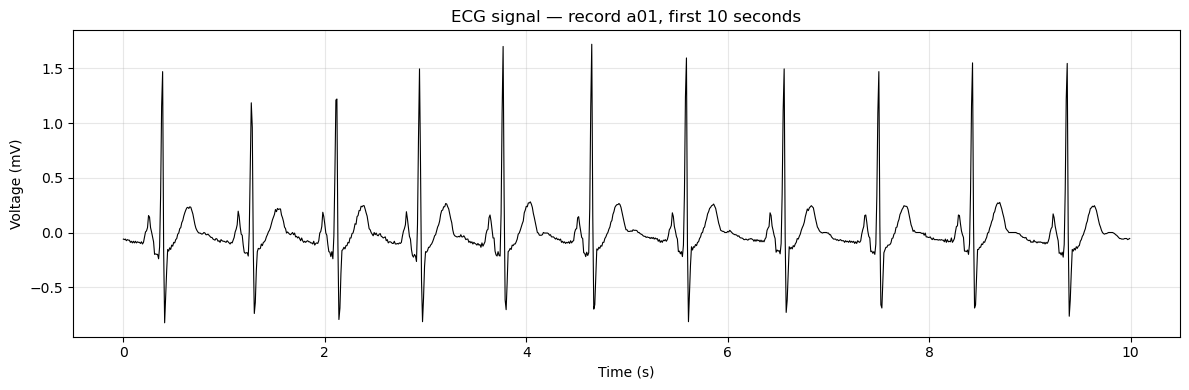

In [4]:
import matplotlib.pyplot as plt
import numpy as np

#first 10 secs of record a01
n_samples = 10 * fs
segment = signal[:n_samples]
time = np.arange(n_samples) / fs

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, segment, linewidth=0.8, color='black')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('ECG signal — record a01, first 10 seconds')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

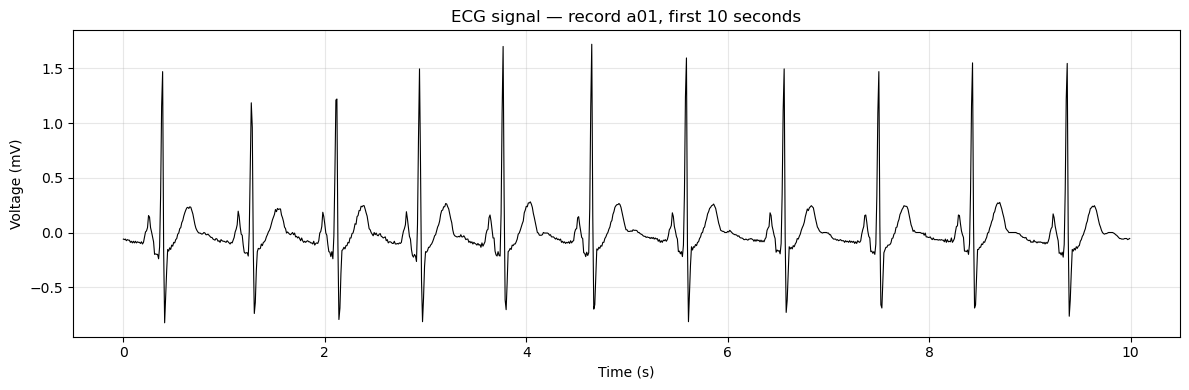

Saved to figures/a01_first10s.png


In [5]:
import os
os.makedirs('figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, segment, linewidth=0.8, color='black')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('ECG signal — record a01, first 10 seconds')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/a01_first10s.png', dpi=150)
plt.show()

print("Saved to figures/a01_first10s.png")

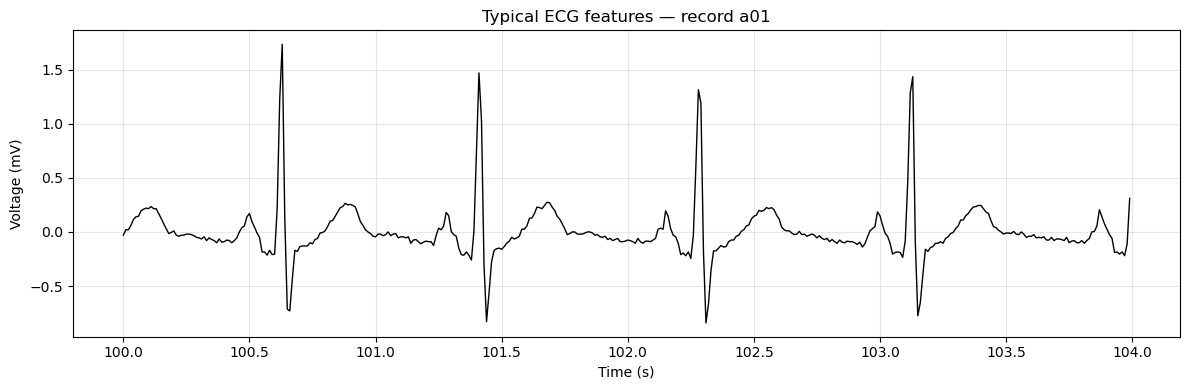

In [6]:
# Pick a clean 4-second window from later in the recording
start_sec = 100
end_sec = 104
seg2 = signal[start_sec*fs : end_sec*fs]
t2 = np.arange(len(seg2)) / fs + start_sec

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t2, seg2, linewidth=1.0, color='black')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('Typical ECG features — record a01')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/typical_features_unlabelled.png', dpi=150)
plt.show()

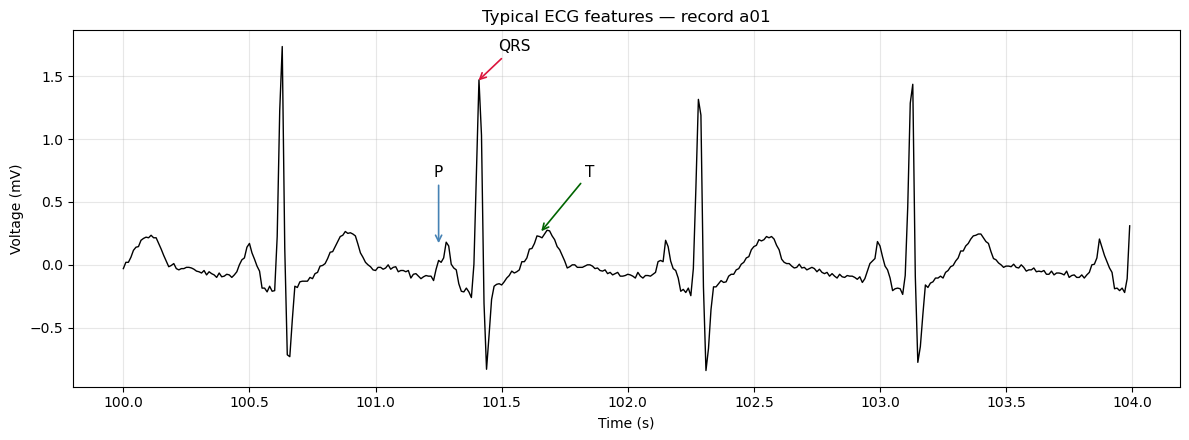

In [7]:
#annotated typical features plot
start_sec = 100
end_sec = 104
seg2 = signal[start_sec*fs : end_sec*fs]
t2 = np.arange(len(seg2)) / fs + start_sec

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(t2, seg2, linewidth=1.0, color='black')

#annotate one representative beat 
ax.annotate('P', xy=(101.25, 0.15), xytext=(101.25, 0.7),
            ha='center', fontsize=11,
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))
ax.annotate('QRS', xy=(101.40, 1.45), xytext=(101.55, 1.7),
            ha='center', fontsize=11,
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))
ax.annotate('T', xy=(101.65, 0.25), xytext=(101.85, 0.7),
            ha='center', fontsize=11,
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.2))

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('Typical ECG features — record a01')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/typical_features.png', dpi=150)
plt.show()

In [8]:
#inspect the apnea annotations
print(f'Total annotations: {len(apnea_ann.symbol)}')
print(f'Unique symbols: {set(apnea_ann.symbol)}')
print(f'Number of apnea minutes: {apnea_ann.symbol.count("A")}')
print(f'Number of normal minutes: {apnea_ann.symbol.count("N")}')
print()
print('First 30 annotations with their minute number:')
for i, sym in enumerate(apnea_ann.symbol[:30]):
    sample_idx = apnea_ann.sample[i]
    minute = sample_idx / fs / 60
    print(f'  Minute {minute:6.1f}: {sym}')

Total annotations: 489
Unique symbols: {'N', 'A'}
Number of apnea minutes: 470
Number of normal minutes: 19

First 30 annotations with their minute number:
  Minute    0.0: N
  Minute    1.0: N
  Minute    2.0: N
  Minute    3.0: N
  Minute    4.0: N
  Minute    5.0: N
  Minute    6.0: N
  Minute    7.0: N
  Minute    8.0: N
  Minute    9.0: N
  Minute   10.0: N
  Minute   11.0: N
  Minute   12.0: N
  Minute   13.0: A
  Minute   14.0: A
  Minute   15.0: A
  Minute   16.0: A
  Minute   17.0: A
  Minute   18.0: A
  Minute   19.0: A
  Minute   20.0: A
  Minute   21.0: A
  Minute   22.0: A
  Minute   23.0: A
  Minute   24.0: A
  Minute   25.0: A
  Minute   26.0: A
  Minute   27.0: A
  Minute   28.0: A
  Minute   29.0: A


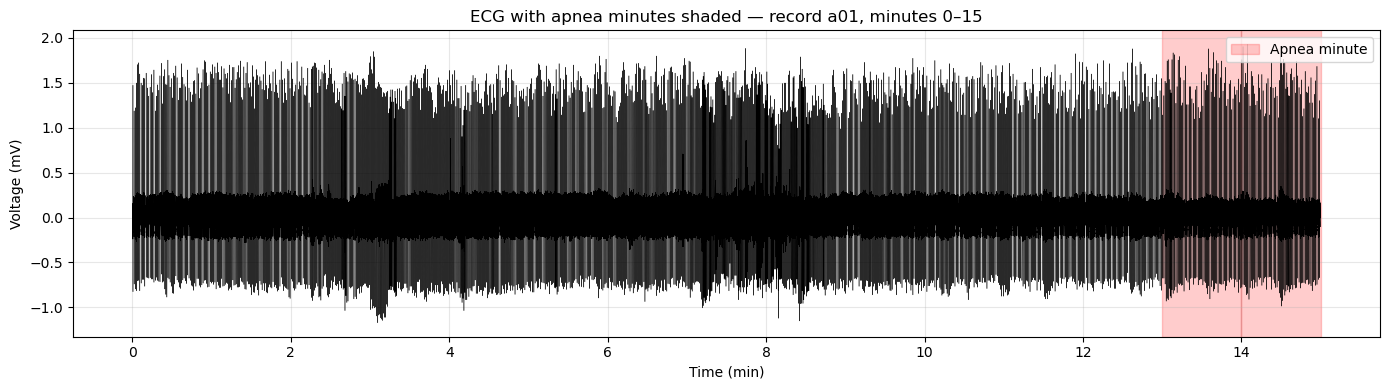

In [9]:
#plot 15 minutes of ECG with apnea minutes shaded
start_min = 0    
end_min = 15
start_sample = start_min * 60 * fs
end_sample = end_min * 60 * fs

segment = signal[start_sample:end_sample]
time_min = np.arange(len(segment)) / fs / 60 + start_min

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_min, segment, linewidth=0.3, color='black')


apnea_label_added = False
for sample_idx, symbol in zip(apnea_ann.sample, apnea_ann.symbol):
    minute = sample_idx / fs / 60
    if start_min <= minute < end_min and symbol == 'A':
        label = 'Apnea minute' if not apnea_label_added else None
        ax.axvspan(minute, minute + 1, alpha=0.2, color='red', label=label)
        apnea_label_added = True

ax.set_xlabel('Time (min)')
ax.set_ylabel('Voltage (mV)')
ax.set_title(f'ECG with apnea minutes shaded — record a01, minutes {start_min}–{end_min}')
ax.grid(True, alpha=0.3)
if apnea_label_added:
    ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/apnea_overlay.png', dpi=150)
plt.show()

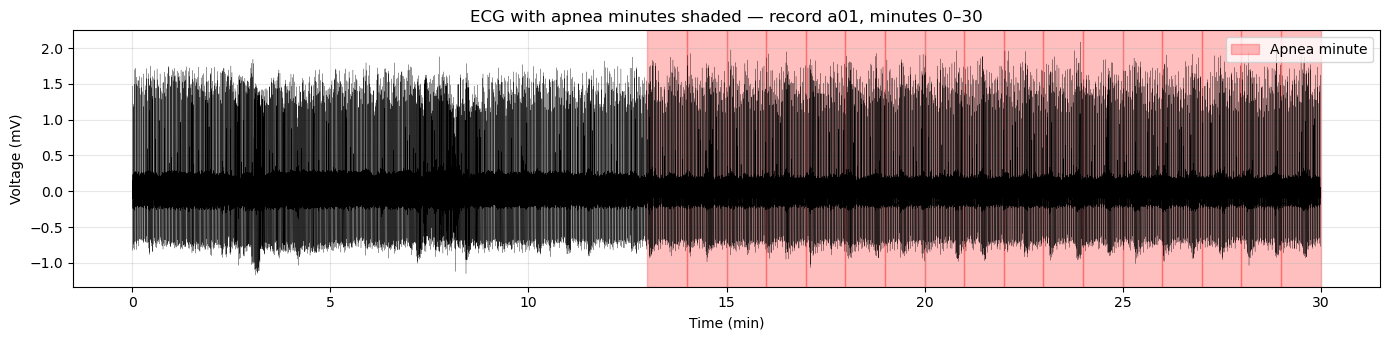

In [10]:
#long-view: 30 min
start_min = 0
end_min = 30
start_sample = start_min * 60 * fs
end_sample = end_min * 60 * fs

segment = signal[start_sample:end_sample]
time_min = np.arange(len(segment)) / fs / 60 + start_min

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(time_min, segment, linewidth=0.15, color='black')

apnea_label_added = False
for sample_idx, symbol in zip(apnea_ann.sample, apnea_ann.symbol):
    minute = sample_idx / fs / 60
    if start_min <= minute < end_min and symbol == 'A':
        label = 'Apnea minute' if not apnea_label_added else None
        ax.axvspan(minute, minute + 1, alpha=0.25, color='red', label=label)
        apnea_label_added = True

ax.set_xlabel('Time (min)')
ax.set_ylabel('Voltage (mV)')
ax.set_title(f'ECG with apnea minutes shaded — record a01, minutes {start_min}–{end_min}')
ax.grid(True, alpha=0.3)
if apnea_label_added:
    ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/apnea_overlay_long.png', dpi=150)
plt.show()

First apnea minute starts at: 13.0 min


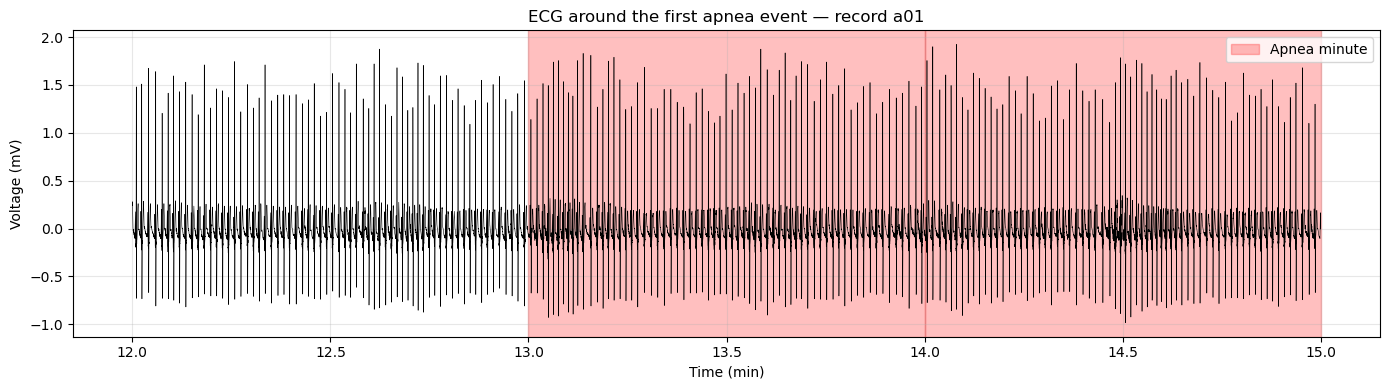

In [11]:
#find the first apnea minute
first_apnea_minute = None
for sample_idx, symbol in zip(apnea_ann.sample, apnea_ann.symbol):
    if symbol == 'A':
        first_apnea_minute = sample_idx / fs / 60
        break

print(f'First apnea minute starts at: {first_apnea_minute:.1f} min')

#plot 1 minute before to 1 minute after
start_min = first_apnea_minute - 1
end_min = first_apnea_minute + 2
start_sample = int(start_min * 60 * fs)
end_sample = int(end_min * 60 * fs)

segment = signal[start_sample:end_sample]
time_min = np.arange(len(segment)) / fs / 60 + start_min

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_min, segment, linewidth=0.4, color='black')


apnea_label_added = False
for sample_idx, symbol in zip(apnea_ann.sample, apnea_ann.symbol):
    minute = sample_idx / fs / 60
    if start_min <= minute < end_min and symbol == 'A':
        label = 'Apnea minute' if not apnea_label_added else None
        ax.axvspan(minute, minute + 1, alpha=0.25, color='red', label=label)
        apnea_label_added = True

ax.set_xlabel('Time (min)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('ECG around the first apnea event — record a01')
ax.grid(True, alpha=0.3)
if apnea_label_added:
    ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/apnea_zoom.png', dpi=150)
plt.show()

c01 length: 483.2 min, annotations: {'N'}


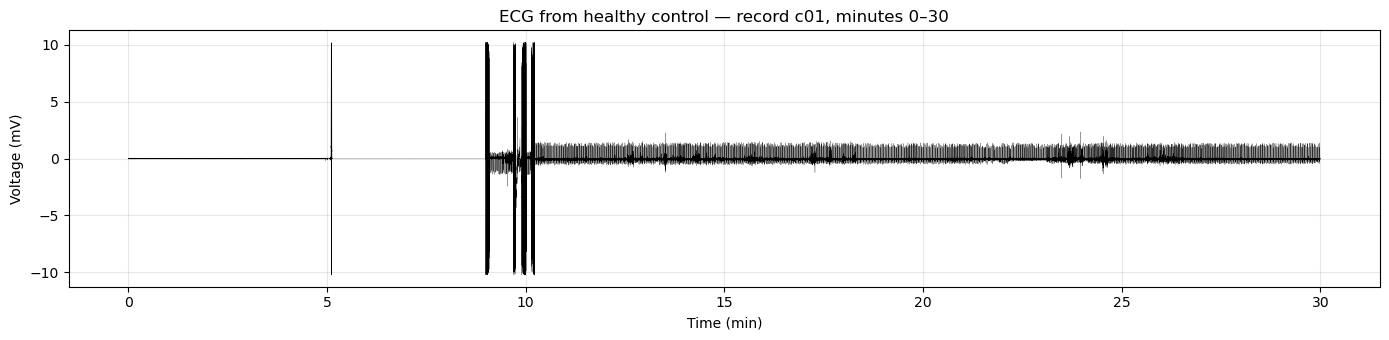

In [12]:
#load a healthy control record
signal_c, fs_c, apnea_c = load_record('c01')
print(f'c01 length: {len(signal_c)/fs_c/60:.1f} min, annotations: {set(apnea_c.symbol) if apnea_c else "none"}')

#plot 30 minutes of c01 
seg_c = signal_c[:30*60*fs_c]
t_c = np.arange(len(seg_c)) / fs_c / 60

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(t_c, seg_c, linewidth=0.15, color='black')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('ECG from healthy control — record c01, minutes 0–30')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/healthy_overlay.png', dpi=150)
plt.show()

In [13]:
from scipy.signal import butter, filtfilt

def bandpass_filter(sig, fs, low=5.0, high=15.0, order=4):
    """
    Zero-phase Butterworth bandpass filter.
    
    Parameters
    
    sig : array_like
        Input signal.
    fs : float
        Sampling frequency in Hz.
    low, high : float
        Cutoff frequencies in Hz.
    order : int
        Filter order.
    
    Returns
   
    Filtered signal, same length as input.
    """
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, sig)

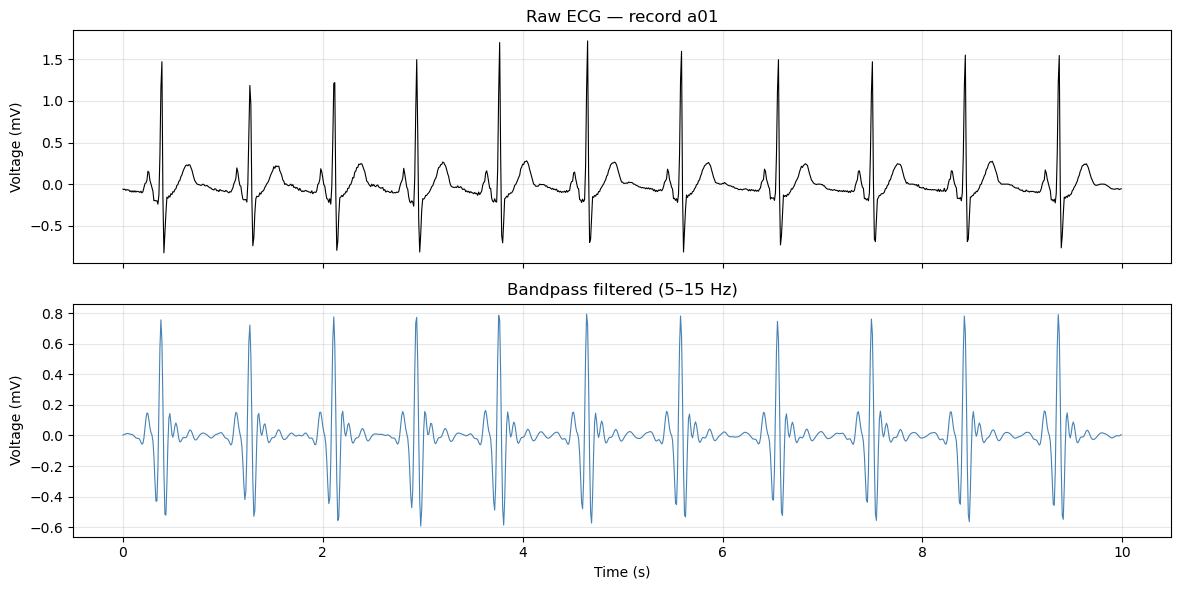

In [14]:
#apply bandpass filter to the first 10 secs
filtered = bandpass_filter(signal, fs)

n_samples = 10 * fs
t = np.arange(n_samples) / fs

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, signal[:n_samples], linewidth=0.8, color='black')
axes[0].set_ylabel('Voltage (mV)')
axes[0].set_title('Raw ECG — record a01')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, filtered[:n_samples], linewidth=0.8, color='steelblue')
axes[1].set_ylabel('Voltage (mV)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Bandpass filtered (5–15 Hz)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/filtering_comparison.png', dpi=150)
plt.show()

In [15]:
from scipy.signal import find_peaks

def pan_tompkins(sig, fs):
    """
    Pan-Tompkins R-peak detector.
    
    Parameters
   
    sig : array_like
        Raw ECG signal.
    fs : float
        Sampling frequency in Hz.
    
    Returns
    
    r_peaks : ndarray
        Sample indices of detected R-peaks.
    diagnostics : dict
        Intermediate signals for inspection/debugging.
    """
    #bandpass
    filtered = bandpass_filter(sig, fs, low=5.0, high=15.0, order=4)
    
    #differentiate
    diff = np.diff(filtered, prepend=filtered[0])
    
    #square
    squared = diff ** 2
    
    #moving-window integrate window ~150 ms, normal QRS width
    window_size = int(0.15 * fs)
    integrated = np.convolve(squared, np.ones(window_size)/window_size, mode='same')
    
    # find peaks above a threshold, with refractory period
    #threshold: 30% of the signal's mean
    threshold = 0.3 * np.mean(integrated) + 0.7 * np.median(integrated)
    # Refractory period: 200 ms
    min_distance = int(0.2 * fs)
    peaks, _ = find_peaks(integrated, height=threshold, distance=min_distance)
    
    #The peaks above are in the integrated signal. They sit slightly after
    #the actual R-peak because of the moving window. 
    #polish by looking for the local maximum in the filtered signal within ±100 ms of each peak.
    search_radius = int(0.1 * fs)
    r_peaks = []
    for p in peaks:
        lo = max(0, p - search_radius)
        hi = min(len(filtered), p + search_radius)
        local_max = lo + np.argmax(filtered[lo:hi])
        r_peaks.append(local_max)
    r_peaks = np.array(r_peaks)
    
    diagnostics = {
        'filtered': filtered,
        'diff': diff,
        'squared': squared,
        'integrated': integrated,
        'threshold': threshold,
    }
    return r_peaks, diagnostics

Detected 29969 R-peaks across the full recording
Average heart rate: 60.8 bpm


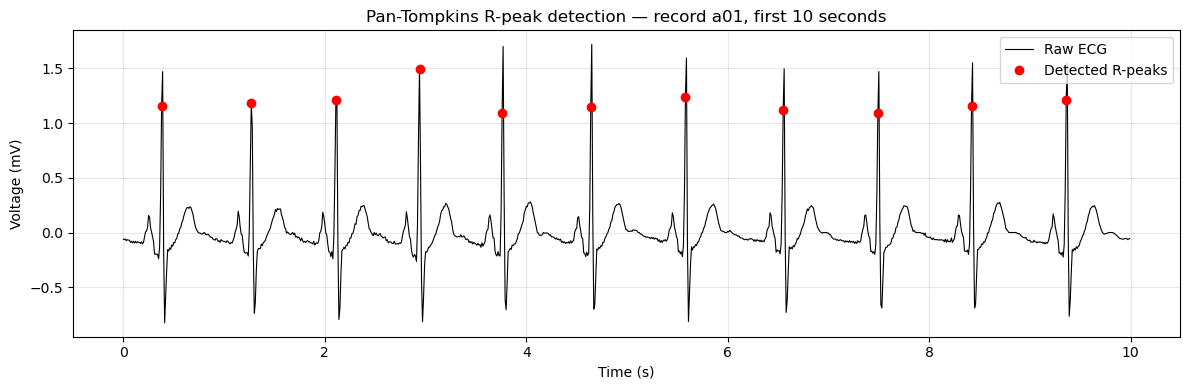

In [16]:
#run detection on the full signal
r_peaks, diag = pan_tompkins(signal, fs)
print(f'Detected {len(r_peaks)} R-peaks across the full recording')
print(f'Average heart rate: {len(r_peaks) / (len(signal)/fs/60):.1f} bpm')

#overlay on the first 10 secs
n_samples = 10 * fs
t = np.arange(n_samples) / fs
peaks_in_window = r_peaks[r_peaks < n_samples]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, signal[:n_samples], linewidth=0.8, color='black', label='Raw ECG')
ax.plot(peaks_in_window/fs, signal[peaks_in_window], 'ro', markersize=6, label='Detected R-peaks')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('Pan-Tompkins R-peak detection — record a01, first 10 seconds')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('figures/rpeak_detection.png', dpi=150)
plt.show()

In [17]:
import wfdb

#load the ground-truth R-peak annotations
qrs_ann = wfdb.rdann('data/a01', 'qrs')
true_peaks = qrs_ann.sample
print(f'Ground-truth R-peaks: {len(true_peaks)}')
print(f'Detected R-peaks: {len(r_peaks)}')

Ground-truth R-peaks: 29938
Detected R-peaks: 29969


In [18]:
def evaluate_detection(detected, truth, fs, tolerance_ms=150):
    """
    Compare detected peaks against ground truth.
    Returns TP, FP, FN, sensitivity, ppv.
    """
    tolerance = int(tolerance_ms / 1000 * fs)
    
    matched_truth = set()
    matched_detected = set()
    
    for i, det in enumerate(detected):
        #finds the closest true peak within tolerance
        diffs = np.abs(truth - det)
        closest = np.argmin(diffs)
        if diffs[closest] <= tolerance and closest not in matched_truth:
            matched_truth.add(closest)
            matched_detected.add(i)
    
    TP = len(matched_detected)
    FP = len(detected) - TP
    FN = len(truth) - TP
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
    
    return TP, FP, FN, sensitivity, ppv

TP, FP, FN, sens, ppv = evaluate_detection(r_peaks, true_peaks, fs)
print(f'True positives:  {TP}')
print(f'False positives: {FP}')
print(f'False negatives: {FN}')
print(f'Sensitivity:     {sens*100:.2f}%')
print(f'Positive predictive value: {ppv*100:.2f}%')

True positives:  29938
False positives: 31
False negatives: 0
Sensitivity:     100.00%
Positive predictive value: 99.90%


In [19]:
records_to_test = ['a01', 'a02', 'a03', 'b01', 'c01', 'c02']

print(f'{"Record":<8}{"Detected":>10}{"Truth":>10}{"TP":>6}{"FP":>6}{"FN":>6}{"Sens %":>10}{"PPV %":>10}')
print('-' * 66)
for rec in records_to_test:
    sig, fs_rec, _ = load_record(rec)
    detected, _ = pan_tompkins(sig, fs_rec)
    qrs = wfdb.rdann(f'data/{rec}', 'qrs')
    TP, FP, FN, sens, ppv = evaluate_detection(detected, qrs.sample, fs_rec)
    print(f'{rec:<8}{len(detected):>10}{len(qrs.sample):>10}{TP:>6}{FP:>6}{FN:>6}{sens*100:>10.2f}{ppv*100:>10.2f}')

Record    Detected     Truth    TP    FP    FN    Sens %     PPV %
------------------------------------------------------------------
a01          29969     29938 29938    31     0    100.00     99.90
a02          49849     35242 35229 14620    13     99.96     70.67
a03          34297     34259 34249    48    10     99.97     99.86
b01          35384     35100 35091   293     9     99.97     99.17
c01          27949     27871 27714   235   157     99.44     99.16
c02          32559     32221 32209   350    12     99.96     98.93


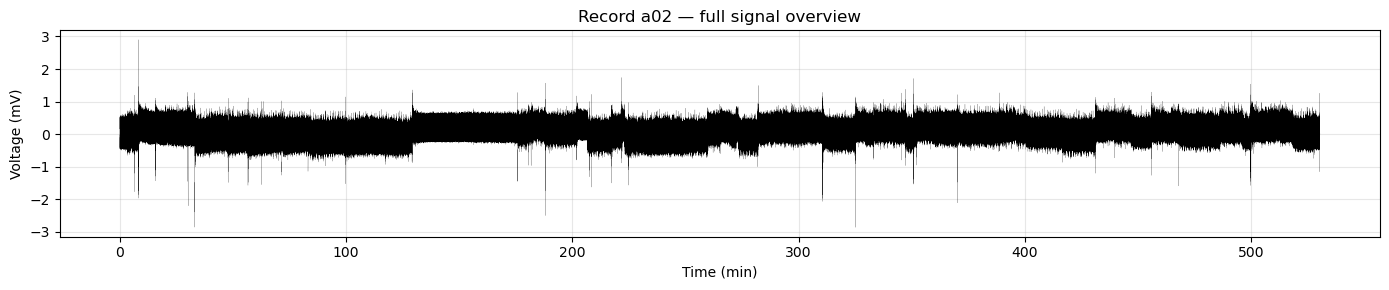

Densest 30s window starts at 480s with 82 detected peaks
(Expected for normal HR: 30-50)


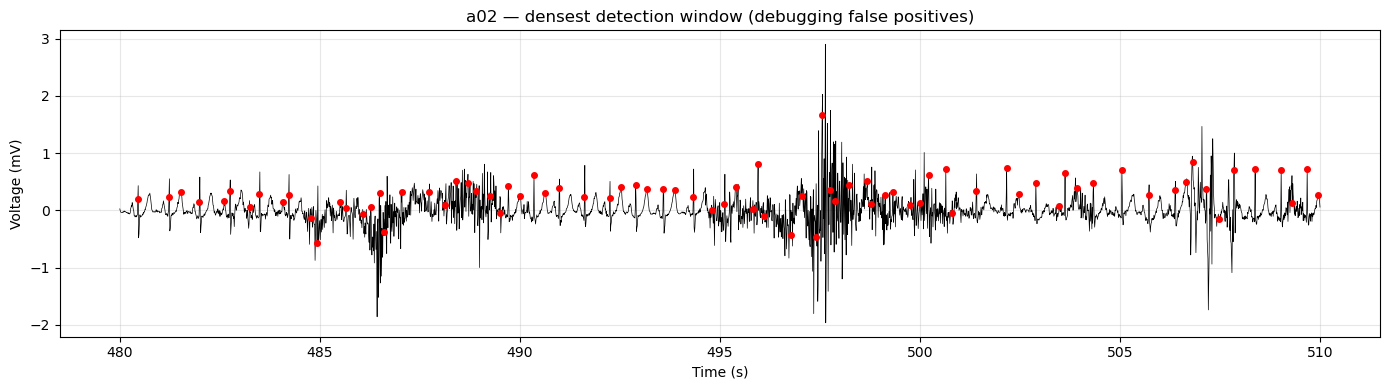

In [20]:
#checks a02
sig_a02, fs_a02, _ = load_record('a02')

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(np.arange(len(sig_a02))/fs_a02/60, sig_a02, linewidth=0.1, color='black')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('Record a02 — full signal overview')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#plot a 30-second window with detected peaks overlaid, in a region
#where the detector is misbehaving
detected_a02, _ = pan_tompkins(sig_a02, fs_a02)

#find a window with abnormally high detection density
window_size = 30 * fs_a02  # 30 seconds
densities = []
for start in range(0, len(sig_a02) - window_size, window_size):
    n_peaks = np.sum((detected_a02 >= start) & (detected_a02 < start + window_size))
    densities.append((start, n_peaks))

#show the densest window
densities.sort(key=lambda x: -x[1])
worst_start, worst_n = densities[0]
print(f'Densest 30s window starts at {worst_start/fs_a02:.0f}s with {worst_n} detected peaks')
print(f'(Expected for normal HR: 30-50)')

t = np.arange(window_size) / fs_a02 + worst_start/fs_a02
seg = sig_a02[worst_start:worst_start+window_size]
peaks_window = detected_a02[(detected_a02 >= worst_start) & (detected_a02 < worst_start+window_size)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, seg, linewidth=0.5, color='black')
ax.plot(peaks_window/fs_a02, sig_a02[peaks_window], 'ro', markersize=4)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('a02 — densest detection window (debugging false positives)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/a02_debug.png', dpi=150)
plt.show()

In [52]:
### Detector validation — a02 failure analysis
'''
a02 produces 14,620 false positives (PPV 70.67%) vs >99% on other records.

probable cause: Visual inspection of the densest detection window (480-510s) shows
heavy high-frequency noise contamination. Signal amplitude is also reduced
(~±0.5 mV vs ~±1.5 mV in a01). The Pan-Tompkins bandpass passes much of
this noise, and the squaring step amplifies it past the detection threshold.
'''

'\na02 produces 14,620 false positives (PPV 70.67%) vs >99% on other records.\n\nprobable cause: Visual inspection of the densest detection window (480-510s) shows\nheavy high-frequency noise contamination. Signal amplitude is also reduced\n(~±0.5 mV vs ~±1.5 mV in a01). The Pan-Tompkins bandpass passes much of\nthis noise, and the squaring step amplifies it past the detection threshold.\n'

In [22]:
def signal_quality_index(sig, fs):
    """
    Simple SQI: ratio of energy in QRS band (5-15 Hz) to high-frequency
    noise band (>30 Hz). Higher = cleaner signal.
    """
    from scipy.signal import welch
    f, psd = welch(sig, fs=fs, nperseg=int(10*fs))
    qrs_band = (f >= 5) & (f <= 15)
    noise_band = f > 30
    return psd[qrs_band].sum() / (psd[noise_band].sum() + 1e-10)

records = ['a01', 'a02', 'a03', 'b01', 'c01', 'c02']
print(f'{"Record":<8}{"SQI":>10}{"PPV %":>10}')
print('-' * 28)
for rec in records:
    sig, fs_rec, _ = load_record(rec)
    sqi = signal_quality_index(sig, fs_rec)
    detected, _ = pan_tompkins(sig, fs_rec)
    qrs = wfdb.rdann(f'data/{rec}', 'qrs')
    _, _, _, _, ppv = evaluate_detection(detected, qrs.sample, fs_rec)
    print(f'{rec:<8}{sqi:>10.2f}{ppv*100:>10.2f}')

Record         SQI     PPV %
----------------------------
a01          29.67     99.90
a02           2.76     70.67
a03          10.67     99.86
b01          36.64     99.17
c01           0.52     99.16
c02           1.30     98.93


In [23]:
#compute R-R intervals from detected R-peaks
rr_times = r_peaks[1:] / fs           #time of each interval (taken at second peak)
rr_intervals = np.diff(r_peaks) / fs  #interval values in seconds

print(f'Number of R-R intervals: {len(rr_intervals)}')
print(f'Mean RR interval: {np.mean(rr_intervals)*1000:.1f} ms')
print(f'Equivalent mean HR: {60/np.mean(rr_intervals):.1f} bpm')
print(f'RR interval range: {np.min(rr_intervals)*1000:.0f}–{np.max(rr_intervals)*1000:.0f} ms')

Number of R-R intervals: 29968
Mean RR interval: 986.5 ms
Equivalent mean HR: 60.8 bpm
RR interval range: 110–1710 ms


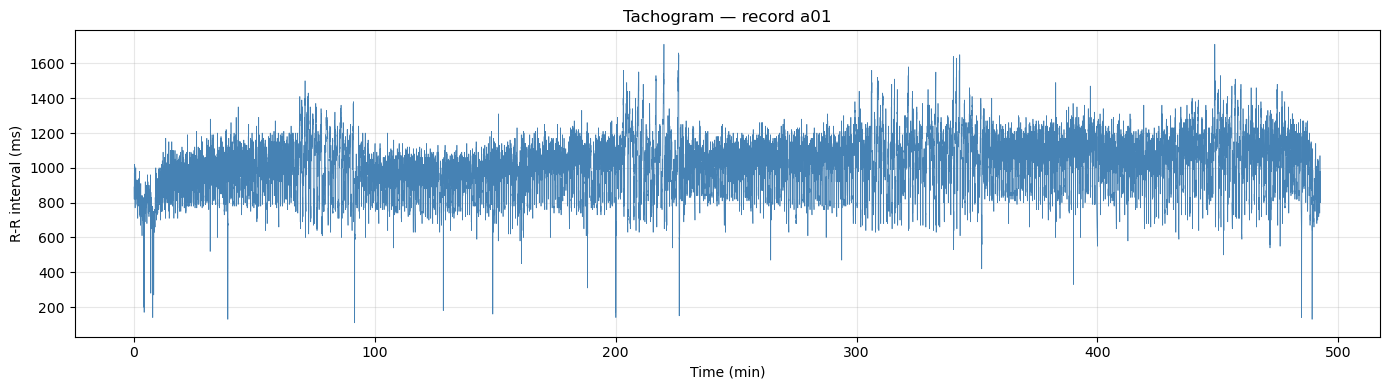

In [24]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rr_times / 60, rr_intervals * 1000, linewidth=0.5, color='steelblue')
ax.set_xlabel('Time (min)')
ax.set_ylabel('R-R interval (ms)')
ax.set_title('Tachogram — record a01')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/tachogram.png', dpi=150)
plt.show()

In [25]:
#plausible RR range for adults: 300 ms (200 bpm) to 2000 ms (30 bpm)
valid = (rr_intervals > 0.3) & (rr_intervals < 2.0)
n_removed = np.sum(~valid)
print(f'Removing {n_removed} implausible intervals ({100*n_removed/len(rr_intervals):.2f}%)')

rr_times_clean = rr_times[valid]
rr_clean = rr_intervals[valid]

Removing 24 implausible intervals (0.08%)


In [26]:
from scipy.interpolate import CubicSpline

# Build the uniform time grid
fs_uniform = 4.0   # Hz; standard for HRV analysis
t_uniform = np.arange(rr_times_clean[0], rr_times_clean[-1], 1/fs_uniform)

# Cubic spline interpolation
cs = CubicSpline(rr_times_clean, rr_clean)
rr_uniform = cs(t_uniform)

print(f'Uniform tachogram: {len(rr_uniform)} samples at {fs_uniform} Hz')
print(f'Duration: {len(rr_uniform)/fs_uniform/60:.1f} min')

Uniform tachogram: 118253 samples at 4.0 Hz
Duration: 492.7 min


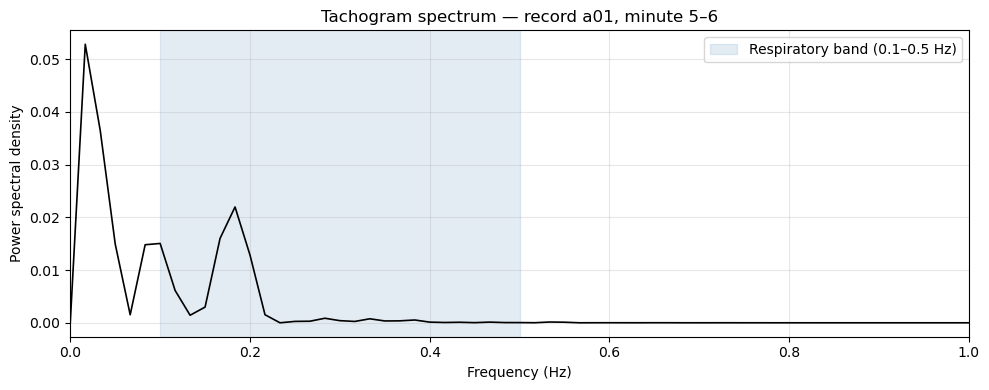

Dominant peak in respiratory band: 0.183 Hz = 11.0 bpm


In [27]:
from scipy.signal import welch

# Take a 60-second window from a clean part of the recording
window_start_min = 5
window_duration_s = 60
i0 = int(window_start_min * 60 * fs_uniform)
i1 = i0 + int(window_duration_s * fs_uniform)

window = rr_uniform[i0:i1]
window = window - np.mean(window)   # detrend to remove DC offset

freqs, psd = welch(window, fs=fs_uniform, nperseg=len(window))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, psd, linewidth=1.2, color='black')
ax.axvspan(0.1, 0.5, alpha=0.15, color='steelblue', label='Respiratory band (0.1–0.5 Hz)')
ax.set_xlim(0, 1.0)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power spectral density')
ax.set_title(f'Tachogram spectrum — record a01, minute {window_start_min}–{window_start_min+1}')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('figures/tachogram_spectrum.png', dpi=150)
plt.show()

# Find the dominant peak in the respiratory band
in_band = (freqs >= 0.1) & (freqs <= 0.5)
peak_freq = freqs[in_band][np.argmax(psd[in_band])]
peak_bpm = peak_freq * 60
print(f'Dominant peak in respiratory band: {peak_freq:.3f} Hz = {peak_bpm:.1f} bpm')

In [28]:
# Quick scan: peak frequency in 5 different 60-second windows
test_minutes = [2, 5, 8, 11, 30]   # mostly normal, then one well into apnea

print(f'{"Minute":<10}{"Peak (Hz)":>12}{"BPM":>8}{"Peak strength":>16}')
print('-' * 46)
for m in test_minutes:
    i0 = int(m * 60 * fs_uniform)
    i1 = i0 + int(60 * fs_uniform)
    if i1 > len(rr_uniform):
        continue
    win = rr_uniform[i0:i1] - np.mean(rr_uniform[i0:i1])
    f_, p_ = welch(win, fs=fs_uniform, nperseg=len(win))
    band = (f_ >= 0.1) & (f_ <= 0.5)
    peak_idx = np.argmax(p_[band])
    pk_freq = f_[band][peak_idx]
    pk_pow = p_[band][peak_idx]
    # Strength = peak power divided by mean power in the band (rough SNR)
    strength = pk_pow / np.mean(p_[band])
    print(f'{m:<10}{pk_freq:>12.3f}{pk_freq*60:>8.1f}{strength:>16.2f}')

Minute       Peak (Hz)     BPM   Peak strength
----------------------------------------------
2                0.150     9.0            6.27
5                0.183    11.0            6.65
8                0.100     6.0           11.42
11               0.100     6.0            4.54
30               0.300    18.0            6.05


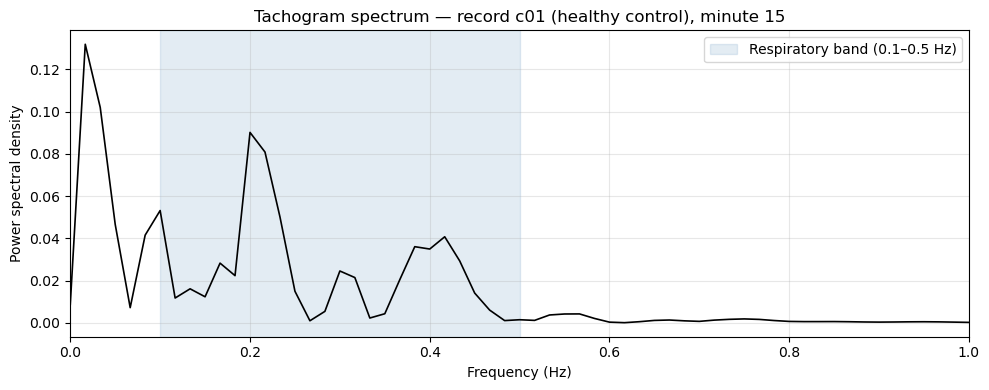

c01 dominant peak: 0.200 Hz = 12.0 bpm


In [29]:
# Run the same spectrum analysis on a HEALTHY control (c01)
sig_c, fs_c, _ = load_record('c01')
peaks_c, _ = pan_tompkins(sig_c, fs_c)

rr_t_c = peaks_c[1:] / fs_c
rr_int_c = np.diff(peaks_c) / fs_c
valid_c = (rr_int_c > 0.3) & (rr_int_c < 2.0)
rr_t_c = rr_t_c[valid_c]
rr_int_c = rr_int_c[valid_c]

# Drop the first ~60s where the c01 artifacts live (you noted this earlier!)
mask = rr_t_c > 600   # skip first 10 min to avoid the artifact spikes
rr_t_c = rr_t_c[mask]
rr_int_c = rr_int_c[mask]

# Resample uniformly
t_uniform_c = np.arange(rr_t_c[0], rr_t_c[-1], 1/fs_uniform)
cs_c = CubicSpline(rr_t_c, rr_int_c)
rr_uniform_c = cs_c(t_uniform_c)

# Spectrum at minute 15 (well past the artifacts)
i0 = int(5 * 60 * fs_uniform)   # 5 minutes into rr_uniform_c (i.e. min 15 absolute)
i1 = i0 + int(60 * fs_uniform)
win_c = rr_uniform_c[i0:i1] - np.mean(rr_uniform_c[i0:i1])
f_c, p_c = welch(win_c, fs=fs_uniform, nperseg=len(win_c))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(f_c, p_c, linewidth=1.2, color='black')
ax.axvspan(0.1, 0.5, alpha=0.15, color='steelblue', label='Respiratory band (0.1–0.5 Hz)')
ax.set_xlim(0, 1.0)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power spectral density')
ax.set_title('Tachogram spectrum — record c01 (healthy control), minute 15')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('figures/spectrum_c01.png', dpi=150)
plt.show()

band = (f_c >= 0.1) & (f_c <= 0.5)
pk = f_c[band][np.argmax(p_c[band])]
print(f'c01 dominant peak: {pk:.3f} Hz = {pk*60:.1f} bpm')

In [30]:
def respiratory_rate_trace(rr_uniform, fs_uniform,
                           window_s=60, step_s=30,
                           band=(0.1, 0.5)):
    """
    Compute time-varying respiratory rate from a uniformly-sampled
    R-R interval series via sliding-window Welch.
    
    Returns
    
    times : ndarray
        Center time of each window (secs).
    bpm : ndarray
        Estimated breaths per minute for each window.
    strength : ndarray
        Peak-to-mean ratio in band  confidence indicator.
    """
    win_n = int(window_s * fs_uniform)
    step_n = int(step_s * fs_uniform)
    
    times, bpm, strength = [], [], []
    for start in range(0, len(rr_uniform) - win_n, step_n):
        seg = rr_uniform[start:start+win_n]
        seg = seg - np.mean(seg)
        f, p = welch(seg, fs=fs_uniform, nperseg=win_n)
        in_band = (f >= band[0]) & (f <= band[1])
        peak_idx = np.argmax(p[in_band])
        peak_freq = f[in_band][peak_idx]
        peak_pow = p[in_band][peak_idx]
        
        times.append((start + win_n/2) / fs_uniform)
        bpm.append(peak_freq * 60)
        strength.append(peak_pow / np.mean(p[in_band]))
    
    return np.array(times), np.array(bpm), np.array(strength)

# Run it for a01
times, bpm, strength = respiratory_rate_trace(rr_uniform, fs_uniform)
print(f'{len(times)} windows analysed')
print(f'BPM range: {bpm.min():.1f} – {bpm.max():.1f}')
print(f'Mean BPM: {bpm.mean():.1f}')
print(f'Strength range: {strength.min():.1f} – {strength.max():.1f}')

984 windows analysed
BPM range: 6.0 – 23.0
Mean BPM: 10.8
Strength range: 2.2 – 16.2


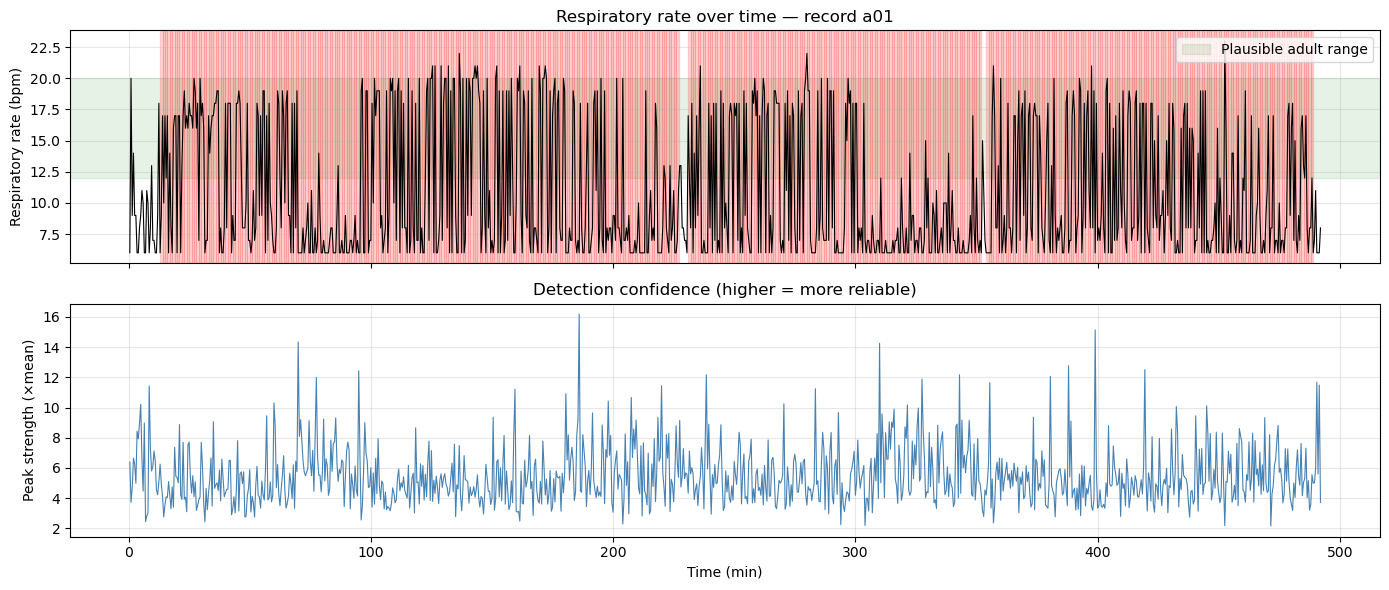

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Top: respiratory rate trace
axes[0].plot(times/60, bpm, linewidth=0.8, color='black')
axes[0].axhspan(12, 20, alpha=0.1, color='green', label='Plausible adult range')
axes[0].set_ylabel('Respiratory rate (bpm)')
axes[0].set_title('Respiratory rate over time — record a01')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

# Shade apnea minutes
for sample_idx, symbol in zip(apnea_ann.sample, apnea_ann.symbol):
    minute = sample_idx / fs / 60
    if symbol == 'A':
        axes[0].axvspan(minute, minute+1, alpha=0.15, color='red')

# Bottom: confidence
axes[1].plot(times/60, strength, linewidth=0.8, color='steelblue')
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('Peak strength (×mean)')
axes[1].set_title('Detection confidence (higher = more reliable)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/respiratory_rate_trace_a01.png', dpi=150)
plt.show()

c01: 945 windows, BPM range 6.0–30.0, mean 10.5


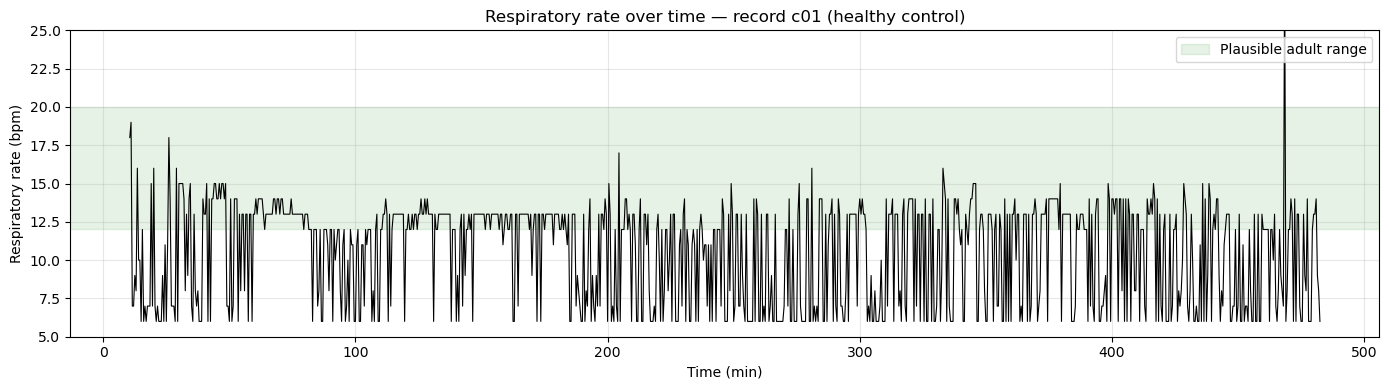

In [32]:
times_c, bpm_c, strength_c = respiratory_rate_trace(rr_uniform_c, fs_uniform)
print(f'c01: {len(times_c)} windows, BPM range {bpm_c.min():.1f}–{bpm_c.max():.1f}, mean {bpm_c.mean():.1f}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(times_c/60 + 10, bpm_c, linewidth=0.8, color='black')   #+10 because we cropped first 10 mins
ax.axhspan(12, 20, alpha=0.1, color='green', label='Plausible adult range')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Respiratory rate (bpm)')
ax.set_title('Respiratory rate over time — record c01 (healthy control)')
ax.set_ylim(5, 25)   #match a01 plot for fair visual comparison
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/respiratory_rate_trace_c01.png', dpi=150)
plt.show()

c01 (band 0.15-0.4 Hz): mean 12.6, range 9.0-21.0
Windows in plausible 12-20 range: 81.8%


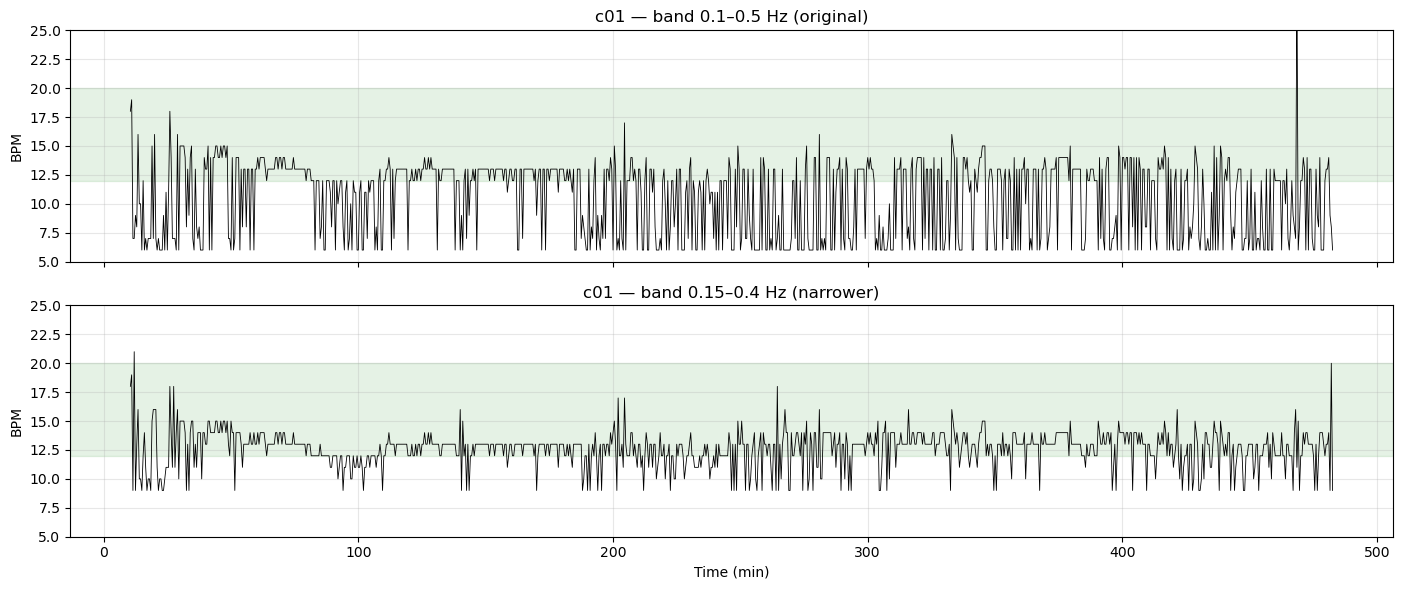

In [33]:
times_c2, bpm_c2, strength_c2 = respiratory_rate_trace(
    rr_uniform_c, fs_uniform,
    window_s=60, step_s=30,
    band=(0.15, 0.4)   
)
print(f'c01 (band 0.15-0.4 Hz): mean {bpm_c2.mean():.1f}, range {bpm_c2.min():.1f}-{bpm_c2.max():.1f}')
print(f'Windows in plausible 12-20 range: {100*np.mean((bpm_c2>=12) & (bpm_c2<=20)):.1f}%')

#Compare side by side
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(times_c/60 + 10, bpm_c, linewidth=0.6, color='black')
axes[0].axhspan(12, 20, alpha=0.1, color='green')
axes[0].set_ylabel('BPM')
axes[0].set_title('c01 — band 0.1–0.5 Hz (original)')
axes[0].set_ylim(5, 25)
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_c2/60 + 10, bpm_c2, linewidth=0.6, color='black')
axes[1].axhspan(12, 20, alpha=0.1, color='green')
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('BPM')
axes[1].set_title('c01 — band 0.15–0.4 Hz (narrower)')
axes[1].set_ylim(5, 25)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/c01_band_comparison.png', dpi=150)
plt.show()

In [34]:
#re-run a01 with narrower band for fair comparison
times_a, bpm_a, strength_a = respiratory_rate_trace(
    rr_uniform, fs_uniform,
    band=(0.15, 0.4)
)
print(f'a01 (band 0.15-0.4): mean {bpm_a.mean():.1f}, range {bpm_a.min():.1f}-{bpm_a.max():.1f}')
print(f'Windows in plausible 12-20 range: {100*np.mean((bpm_a>=12) & (bpm_a<=20)):.1f}%')

a01 (band 0.15-0.4): mean 15.0, range 9.0-23.0
Windows in plausible 12-20 range: 65.1%


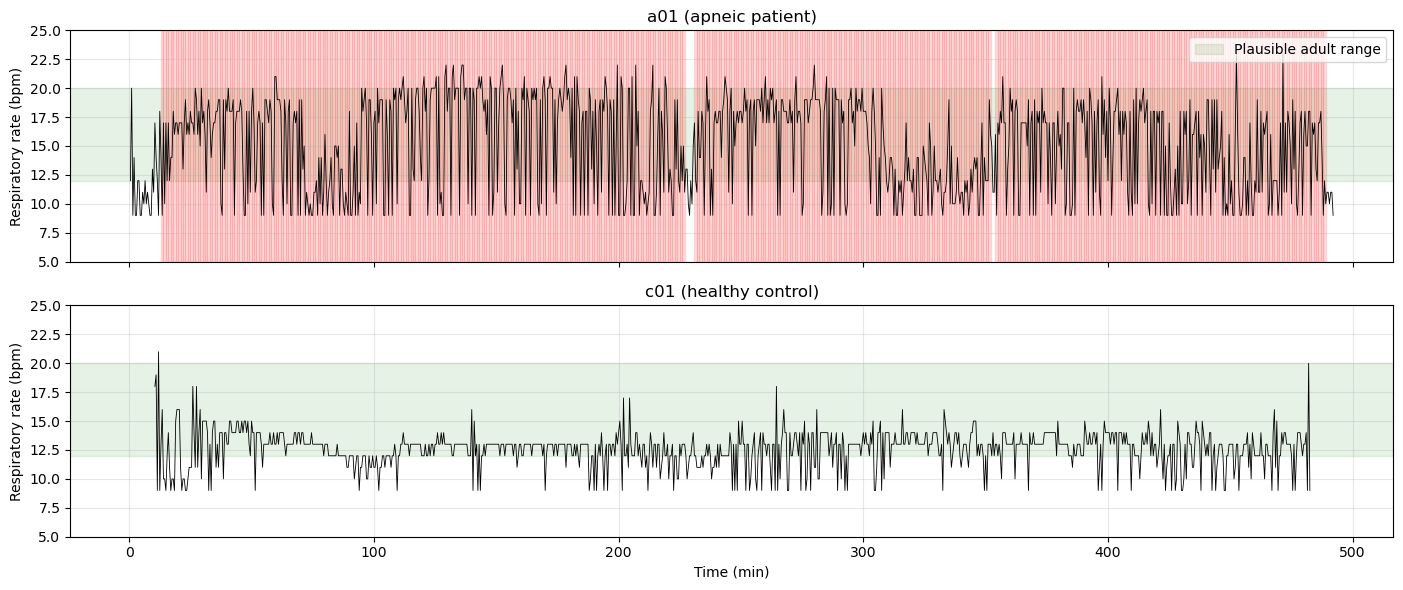

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# a01 (apneic) on top
axes[0].plot(times_a/60, bpm_a, linewidth=0.6, color='black')
axes[0].axhspan(12, 20, alpha=0.1, color='green', label='Plausible adult range')
# Shade apnea minutes
for sample_idx, symbol in zip(apnea_ann.sample, apnea_ann.symbol):
    minute = sample_idx / fs / 60
    if symbol == 'A':
        axes[0].axvspan(minute, minute+1, alpha=0.12, color='red')
axes[0].set_ylabel('Respiratory rate (bpm)')
axes[0].set_title('a01 (apneic patient)')
axes[0].set_ylim(5, 25)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

# c01 (healthy) on bottom
axes[1].plot(times_c2/60 + 10, bpm_c2, linewidth=0.6, color='black')
axes[1].axhspan(12, 20, alpha=0.1, color='green')
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('Respiratory rate (bpm)')
axes[1].set_title('c01 (healthy control)')
axes[1].set_ylim(5, 25)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/respiratory_rate_a01_vs_c01.png', dpi=150)
plt.show()

In [36]:
def analyse_record(record_name, fs_uniform=4.0,
                   band=(0.15, 0.4),
                   window_s=60, step_s=30,
                   skip_first_min=0):
    """
    Runs the full pipeline on a single record and returns summary metrics.
    
    """
    sig, fs_rec, _ = load_record(record_name)
    peaks, _ = pan_tompkins(sig, fs_rec)
    
    rr_t = peaks[1:] / fs_rec
    rr_i = np.diff(peaks) / fs_rec
    valid = (rr_i > 0.3) & (rr_i < 2.0)
    rr_t = rr_t[valid]
    rr_i = rr_i[valid]
    
    if skip_first_min > 0:
        mask = rr_t > skip_first_min * 60
        rr_t = rr_t[mask]
        rr_i = rr_i[mask]
    
    t_uniform = np.arange(rr_t[0], rr_t[-1], 1/fs_uniform)
    cs = CubicSpline(rr_t, rr_i)
    rr_uniform = cs(t_uniform)
    
    times, bpm, strength = respiratory_rate_trace(
        rr_uniform, fs_uniform,
        window_s=window_s, step_s=step_s,
        band=band
    )
    
    return {
        'record': record_name,
        'n_windows': len(bpm),
        'mean_bpm': float(np.mean(bpm)),
        'std_bpm': float(np.std(bpm)),
        'pct_plausible': float(100 * np.mean((bpm >= 12) & (bpm <= 20))),
        'mean_strength': float(np.mean(strength)),
    }

In [37]:
print(analyse_record('a01'))

{'record': 'a01', 'n_windows': 984, 'mean_bpm': 14.957317073170731, 'std_bpm': 4.151379352152832, 'pct_plausible': 65.14227642276423, 'mean_strength': 3.7423922533413276}


In [38]:
apneic_records = ['a01', 'a03', 'a04', 'a05']
healthy_records = ['c01', 'c02', 'c03', 'c04']

results = []

for rec in apneic_records:
    print(f'Processing {rec}...', end=' ')
    try:
        #c01 had artifacts; if any apneic record also has issues, skip first minute
        r = analyse_record(rec, skip_first_min=0)
        r['group'] = 'apneic'
        results.append(r)
        print(f'mean {r["mean_bpm"]:.1f} bpm, {r["pct_plausible"]:.1f}% plausible')
    except Exception as e:
        print(f'FAILED: {e}')

for rec in healthy_records:
    print(f'Processing {rec}...', end=' ')
    try:
        r = analyse_record(rec, skip_first_min=10)   
        r['group'] = 'healthy'
        results.append(r)
        print(f'mean {r["mean_bpm"]:.1f} bpm, {r["pct_plausible"]:.1f}% plausible')
    except Exception as e:
        print(f'FAILED: {e}')

Processing a01... mean 15.0 bpm, 65.1% plausible
Processing a03... mean 12.7 bpm, 34.2% plausible
Processing a04... mean 14.0 bpm, 57.8% plausible
Processing a05... mean 12.4 bpm, 59.9% plausible
Processing c01... mean 12.6 bpm, 81.8% plausible
Processing c02... mean 13.7 bpm, 84.8% plausible
Processing c03... mean 13.0 bpm, 75.1% plausible
Processing c04... mean 17.4 bpm, 69.2% plausible


In [39]:
print(f'{"Record":<10}{"Group":<10}{"Windows":>10}{"Mean BPM":>10}{"Std BPM":>10}{"% Plausible":>14}{"Strength":>12}')
print('-' * 76)
for r in results:
    print(f'{r["record"]:<10}{r["group"]:<10}{r["n_windows"]:>10}'
          f'{r["mean_bpm"]:>10.1f}{r["std_bpm"]:>10.1f}'
          f'{r["pct_plausible"]:>14.1f}{r["mean_strength"]:>12.2f}')

#Group summaries
apneic = [r for r in results if r['group'] == 'apneic']
healthy = [r for r in results if r['group'] == 'healthy']

print()
print('Group summaries:')
print(f'  Apneic  (n={len(apneic)}): % plausible = '
      f'{np.mean([r["pct_plausible"] for r in apneic]):.1f} ± '
      f'{np.std([r["pct_plausible"] for r in apneic]):.1f}')
print(f'  Healthy (n={len(healthy)}): % plausible = '
      f'{np.mean([r["pct_plausible"] for r in healthy]):.1f} ± '
      f'{np.std([r["pct_plausible"] for r in healthy]):.1f}')

Record    Group        Windows  Mean BPM   Std BPM   % Plausible    Strength
----------------------------------------------------------------------------
a01       apneic           984      15.0       4.2          65.1        3.74
a03       apneic          1043      12.7       4.2          34.2        4.27
a04       apneic           991      14.0       4.0          57.8        3.12
a05       apneic           905      12.4       2.5          59.9        4.57
c01       healthy          945      12.6       1.6          81.8        5.73
c02       healthy          981      13.7       2.2          84.8        5.18
c03       healthy          885      13.0       2.3          75.1        4.81
c04       healthy          935      17.4       3.7          69.2        5.01

Group summaries:
  Apneic  (n=4): % plausible = 54.3 ± 11.9
  Healthy (n=4): % plausible = 77.7 ± 6.0


In [40]:
from scipy.stats import mannwhitneyu

apneic_pct = [r['pct_plausible'] for r in results if r['group']=='apneic']
healthy_pct = [r['pct_plausible'] for r in results if r['group']=='healthy']

u, p = mannwhitneyu(healthy_pct, apneic_pct, alternative='greater')
print(f'Apneic %: {apneic_pct}')
print(f'Healthy %: {healthy_pct}')
print(f'Mann-Whitney U: U={u}, p={p:.4f}')

Apneic %: [65.14227642276423, 34.22818791946309, 57.820383451059534, 59.889502762430936]
Healthy %: [81.7989417989418, 84.81141692150867, 75.14124293785311, 69.19786096256685]
Mann-Whitney U: U=16.0, p=0.0143


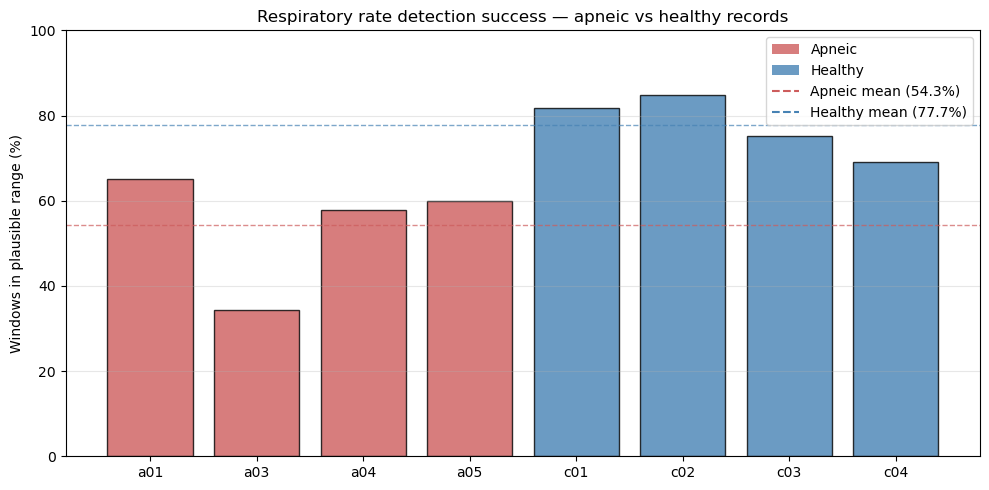

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

#Bar chart with per-record bars
records = [r['record'] for r in results]
percents = [r['pct_plausible'] for r in results]
groups = [r['group'] for r in results]
colors = ['indianred' if g == 'apneic' else 'steelblue' for g in groups]

x = np.arange(len(records))
bars = ax.bar(x, percents, color=colors, alpha=0.8, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(records)
ax.set_ylabel('Windows in plausible range (%)')
ax.set_title('Respiratory rate detection success — apneic vs healthy records')
ax.axhline(np.mean([r['pct_plausible'] for r in results if r['group']=='apneic']),
           color='indianred', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Apneic mean ({np.mean([r["pct_plausible"] for r in results if r["group"]=="apneic"]):.1f}%)')
ax.axhline(np.mean([r['pct_plausible'] for r in results if r['group']=='healthy']),
           color='steelblue', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Healthy mean ({np.mean([r["pct_plausible"] for r in results if r["group"]=="healthy"]):.1f}%)')

#Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='indianred', alpha=0.8, label='Apneic'),
    Patch(facecolor='steelblue', alpha=0.8, label='Healthy'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color='indianred', linestyle='--', label=f'Apneic mean ({np.mean([r["pct_plausible"] for r in results if r["group"]=="apneic"]):.1f}%)'),
    plt.Line2D([0], [0], color='steelblue', linestyle='--', label=f'Healthy mean ({np.mean([r["pct_plausible"] for r in results if r["group"]=="healthy"]):.1f}%)'),
])
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/group_comparison.png', dpi=150)
plt.show()

In [42]:
def extract_amplitudes(sig, peaks, refine_window_samples=0):
    """
    Read R-peak amplitudes from the raw signal.
    
    refine_window_samples: if > 0, take the local maximum in a window
    of ±this many samples around each peak index. Useful when peak
    detection landed slightly off the true peak.
    """
    if refine_window_samples == 0:
        return sig[peaks]
    
    amplitudes = np.empty(len(peaks))
    for i, p in enumerate(peaks):
        lo = max(0, p - refine_window_samples)
        hi = min(len(sig), p + refine_window_samples)
        amplitudes[i] = np.max(sig[lo:hi])
    return amplitudes

#test on a01
amps_a01 = extract_amplitudes(signal, r_peaks)
print(f'R-peak amplitudes for a01:')
print(f'  n = {len(amps_a01)}')
print(f'  mean = {np.mean(amps_a01):.3f} mV')
print(f'  range = {np.min(amps_a01):.3f} – {np.max(amps_a01):.3f} mV')
print(f'  std = {np.std(amps_a01):.3f} mV')

R-peak amplitudes for a01:
  n = 29969
  mean = 1.264 mV
  range = -0.240 – 2.180 mV
  std = 0.225 mV


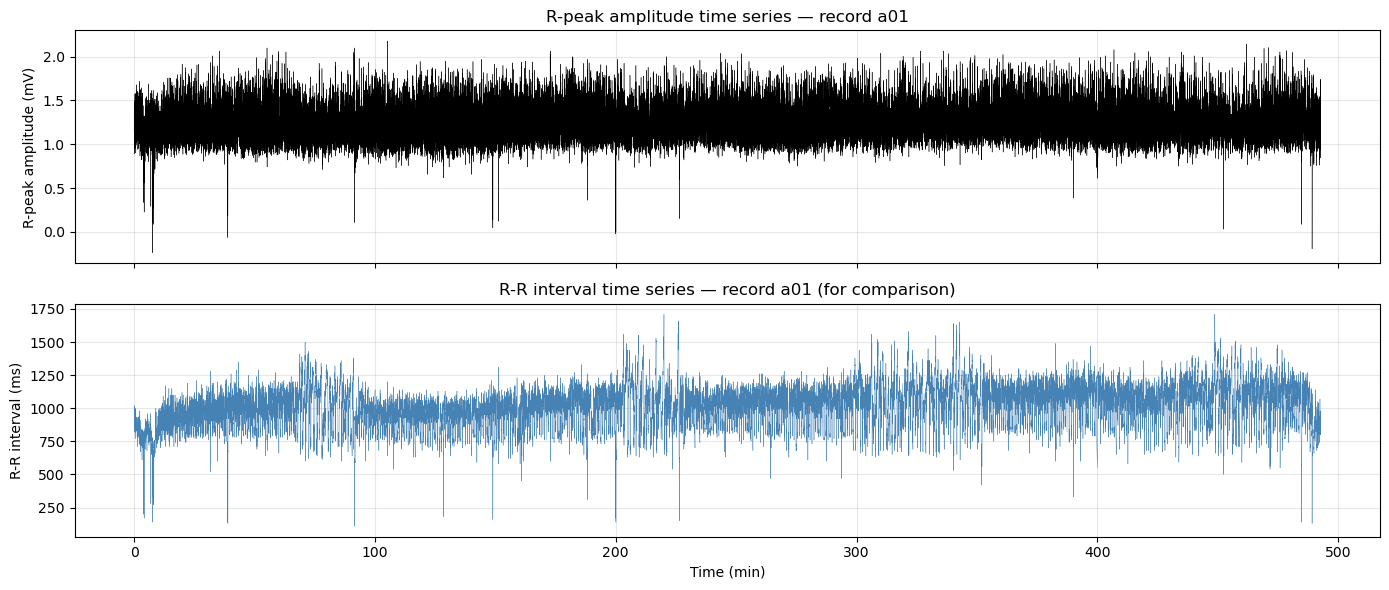

In [43]:
#plot R-peak amplitudes over time
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

#amplitudes
axes[0].plot(r_peaks/fs/60, amps_a01, linewidth=0.3, color='black')
axes[0].set_ylabel('R-peak amplitude (mV)')
axes[0].set_title('R-peak amplitude time series — record a01')
axes[0].grid(True, alpha=0.3)

#for comparison, the R-R intervals (tachogram)
axes[1].plot(rr_times/60, rr_intervals*1000, linewidth=0.3, color='steelblue')
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('R-R interval (ms)')
axes[1].set_title('R-R interval time series — record a01 (for comparison)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/amplitude_vs_tachogram_a01.png', dpi=150)
plt.show()

In [44]:
def edr_respiratory_rate(sig, peaks, fs_orig,
                        fs_uniform=4.0,
                        window_s=60, step_s=30,
                        band=(0.15, 0.4),
                        amplitude_clean=True):
    """
    Compute respiratory rate trace using R-peak amplitude modulation.
    
    Parameters
   
    sig : ECG signal (raw)
    peaks : R-peak indices
    fs_orig : ECG sampling frequency
    
    Returns
    
    times : ndarray (secs)
    bpm : ndarray
    strength : ndarray
    """
    #Extract amplitudes at peak times
    amps = extract_amplitudes(sig, peaks)
    amp_times = peaks / fs_orig
    
    # remove obvious outliers >3 std from median (not a must)
    if amplitude_clean:
        med = np.median(amps)
        mad = np.median(np.abs(amps - med))
        valid = np.abs(amps - med) < 5 * mad
        amps = amps[valid]
        amp_times = amp_times[valid]
    
    #resample amplitudes to uniform 4 Hz grid via cubic spline
    t_uniform = np.arange(amp_times[0], amp_times[-1], 1/fs_uniform)
    cs = CubicSpline(amp_times, amps)
    amps_uniform = cs(t_uniform)
    
    #sliding window Welch + dominant peak in respiratory band
    win_n = int(window_s * fs_uniform)
    step_n = int(step_s * fs_uniform)
    
    times, bpm, strength = [], [], []
    for start in range(0, len(amps_uniform) - win_n, step_n):
        seg = amps_uniform[start:start+win_n]
        seg = seg - np.mean(seg)   # detrend
        f, p = welch(seg, fs=fs_uniform, nperseg=win_n)
        in_band = (f >= band[0]) & (f <= band[1])
        peak_idx = np.argmax(p[in_band])
        peak_freq = f[in_band][peak_idx]
        peak_pow = p[in_band][peak_idx]
        
        times.append((start + win_n/2) / fs_uniform)
        bpm.append(peak_freq * 60)
        strength.append(peak_pow / np.mean(p[in_band]))
    
    return np.array(times), np.array(bpm), np.array(strength)

#Run on a01
times_edr, bpm_edr, strength_edr = edr_respiratory_rate(signal, r_peaks, fs)
print(f'EDR results for a01:')
print(f'  {len(times_edr)} windows')
print(f'  Mean BPM: {bpm_edr.mean():.1f}')
print(f'  Range: {bpm_edr.min():.1f}–{bpm_edr.max():.1f}')
print(f'  % plausible (12-20): {100*np.mean((bpm_edr>=12) & (bpm_edr<=20)):.1f}')

EDR results for a01:
  984 windows
  Mean BPM: 17.3
  Range: 9.0–24.0
  % plausible (12-20): 71.1


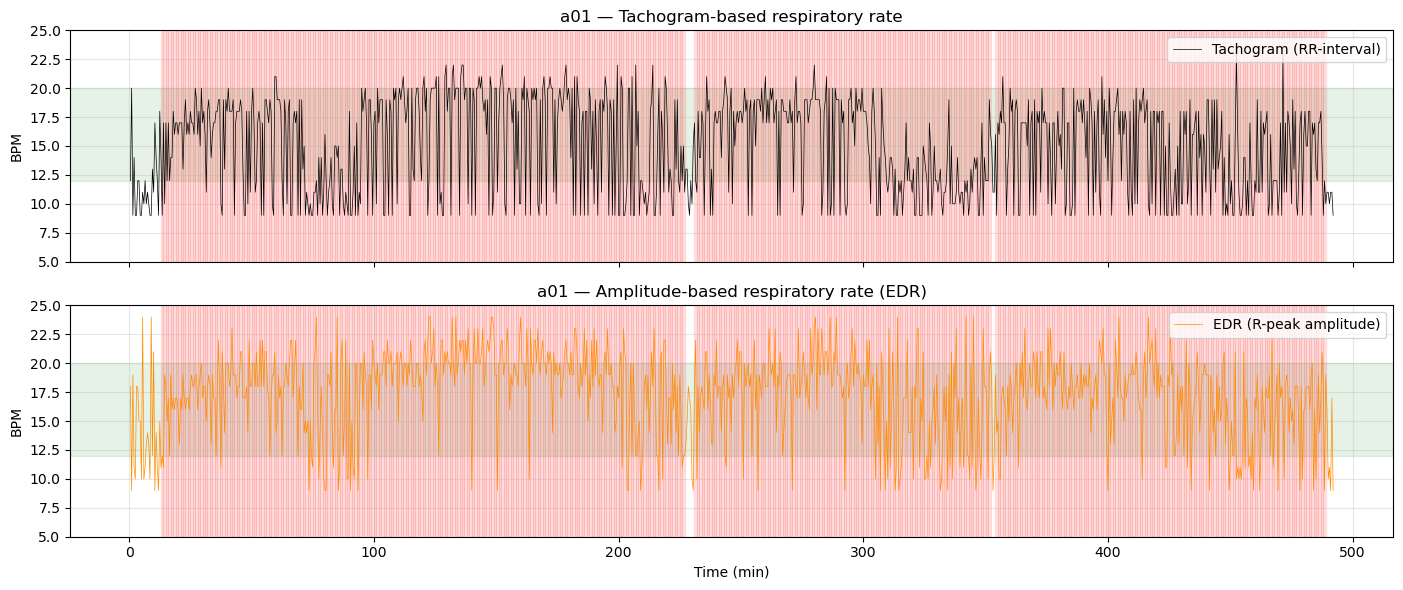


Method comparison (a01):
  Tachogram:  mean 15.0 bpm, 65.1% plausible
  EDR:        mean 17.3 bpm, 71.1% plausible


In [45]:
#re-run tachogram with current parameters for direct comparison
times_tach, bpm_tach, strength_tach = respiratory_rate_trace(
    rr_uniform, fs_uniform, band=(0.15, 0.4)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

#1 tachogram method
axes[0].plot(times_tach/60, bpm_tach, linewidth=0.5, color='black', label='Tachogram (RR-interval)')
axes[0].axhspan(12, 20, alpha=0.1, color='green')
for sample_idx, symbol in zip(apnea_ann.sample, apnea_ann.symbol):
    minute = sample_idx / fs / 60
    if symbol == 'A':
        axes[0].axvspan(minute, minute+1, alpha=0.10, color='red')
axes[0].set_ylabel('BPM')
axes[0].set_title('a01 — Tachogram-based respiratory rate')
axes[0].set_ylim(5, 25)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

#2 EDR method
axes[1].plot(times_edr/60, bpm_edr, linewidth=0.5, color='darkorange', label='EDR (R-peak amplitude)')
axes[1].axhspan(12, 20, alpha=0.1, color='green')
for sample_idx, symbol in zip(apnea_ann.sample, apnea_ann.symbol):
    minute = sample_idx / fs / 60
    if symbol == 'A':
        axes[1].axvspan(minute, minute+1, alpha=0.10, color='red')
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('BPM')
axes[1].set_title('a01 — Amplitude-based respiratory rate (EDR)')
axes[1].set_ylim(5, 25)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('figures/methods_comparison_a01.png', dpi=150)
plt.show()

#quantitative agreement
print(f'\nMethod comparison (a01):')
print(f'  Tachogram:  mean {bpm_tach.mean():.1f} bpm, {100*np.mean((bpm_tach>=12)&(bpm_tach<=20)):.1f}% plausible')
print(f'  EDR:        mean {bpm_edr.mean():.1f} bpm, {100*np.mean((bpm_edr>=12)&(bpm_edr<=20)):.1f}% plausible')

In [46]:
#need to interpolate to common time grid for direct comparison
common_times = times_tach   
bpm_edr_interp = np.interp(common_times, times_edr, bpm_edr)

#correlation across the whole recording
corr = np.corrcoef(bpm_tach, bpm_edr_interp)[0, 1]
print(f'Whole-recording correlation: r = {corr:.3f}')

#correlation in the pre-apnea period only (first 13 minutes)
pre_apnea = common_times < 13 * 60
corr_pre = np.corrcoef(bpm_tach[pre_apnea], bpm_edr_interp[pre_apnea])[0, 1]
print(f'Pre-apnea correlation (minutes 0-13): r = {corr_pre:.3f}')

#correlation during apnea (minutes 13+)
apnea_period = common_times >= 13 * 60
corr_apn = np.corrcoef(bpm_tach[apnea_period], bpm_edr_interp[apnea_period])[0, 1]
print(f'Apnea period correlation (minutes 13+): r = {corr_apn:.3f}')

#mean absolute difference
diff = np.abs(bpm_tach - bpm_edr_interp)
print(f'\nMean absolute difference: {diff.mean():.1f} bpm')
print(f'Median absolute difference: {np.median(diff):.1f} bpm')

Whole-recording correlation: r = 0.240
Pre-apnea correlation (minutes 0-13): r = -0.243
Apnea period correlation (minutes 13+): r = 0.238

Mean absolute difference: 3.8 bpm
Median absolute difference: 2.0 bpm


In [47]:
#EDR on c01
sig_c, fs_c, _ = load_record('c01')
peaks_c, _ = pan_tompkins(sig_c, fs_c)

times_edr_c, bpm_edr_c, _ = edr_respiratory_rate(sig_c, peaks_c, fs_c)
print(f'EDR on c01: mean {bpm_edr_c.mean():.1f} bpm, '
      f'{100*np.mean((bpm_edr_c>=12)&(bpm_edr_c<=20)):.1f}% plausible')
print(f'Compare to tachogram c01: 81.8% plausible')

EDR on c01: mean 13.2 bpm, 91.2% plausible
Compare to tachogram c01: 81.8% plausible


In [48]:
#EDR across all records
edr_results = []
for rec in apneic_records + healthy_records:
    sig_r, fs_r, _ = load_record(rec)
    peaks_r, _ = pan_tompkins(sig_r, fs_r)
    #Skips first 10 min for healthy controls (artifacts)
    skip_samples = 10 * 60 * fs_r if rec.startswith('c') else 0
    valid_peaks = peaks_r[peaks_r > skip_samples] if skip_samples > 0 else peaks_r
    
    try:
        t_e, b_e, _ = edr_respiratory_rate(sig_r, valid_peaks, fs_r)
        pct = 100*np.mean((b_e>=12)&(b_e<=20))
        edr_results.append({'record': rec, 'group': 'apneic' if rec.startswith('a') else 'healthy',
                           'mean_bpm': b_e.mean(), 'pct': pct})
        print(f'{rec}: EDR mean {b_e.mean():.1f}, {pct:.1f}% plausible')
    except Exception as e:
        print(f'{rec}: FAILED ({e})')

#group summary
ap_pct = [r['pct'] for r in edr_results if r['group']=='apneic']
he_pct = [r['pct'] for r in edr_results if r['group']=='healthy']
print(f'\nEDR group summaries:')
print(f'  Apneic  (n={len(ap_pct)}): {np.mean(ap_pct):.1f} ± {np.std(ap_pct):.1f}')
print(f'  Healthy (n={len(he_pct)}): {np.mean(he_pct):.1f} ± {np.std(he_pct):.1f}')

a01: EDR mean 17.3, 71.1% plausible
a03: EDR mean 15.1, 58.3% plausible
a04: EDR mean 15.5, 62.6% plausible
a05: EDR mean 14.5, 58.5% plausible
c01: EDR mean 13.1, 90.1% plausible
c02: EDR mean 15.7, 59.2% plausible
c03: EDR mean 14.4, 67.5% plausible
c04: EDR mean 15.5, 59.2% plausible

EDR group summaries:
  Apneic  (n=4): 62.6 ± 5.2
  Healthy (n=4): 69.0 ± 12.7


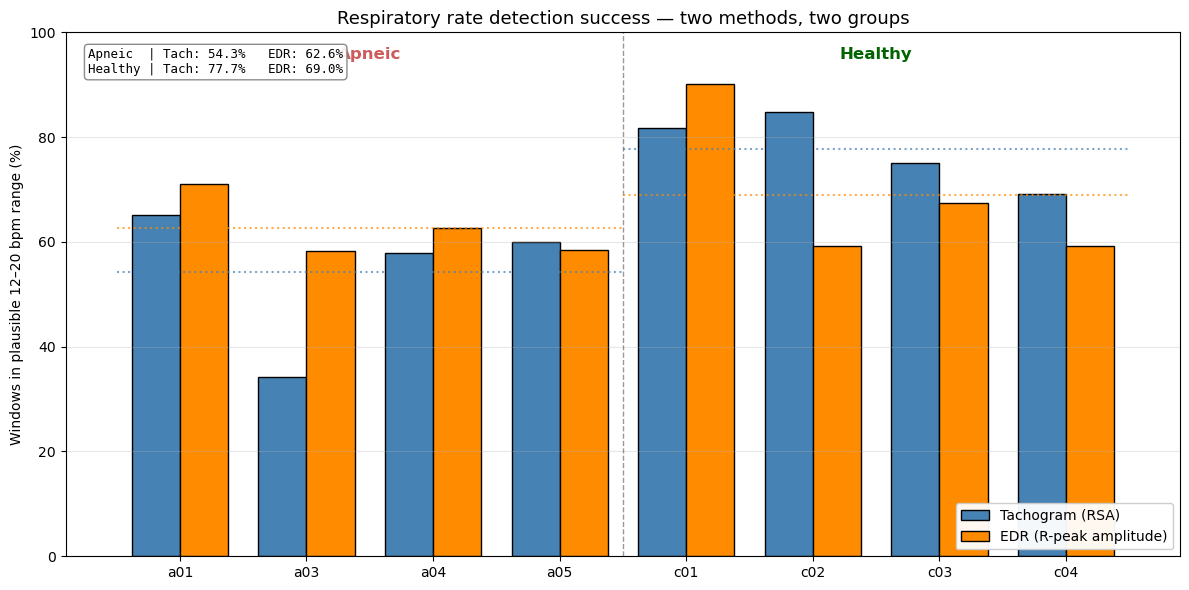

In [49]:
#builds a results table merging tachogram and EDR
records_ordered = ['a01', 'a03', 'a04', 'a05', 'c01', 'c02', 'c03', 'c04']

#Pulls tachogram results from results list, EDR from edr_results list
tach_pct = {r['record']: r['pct_plausible'] for r in results}
edr_pct = {r['record']: r['pct'] for r in edr_results}

tach_values = [tach_pct[r] for r in records_ordered]
edr_values = [edr_pct[r] for r in records_ordered]

#Group means
tach_apneic = np.mean([tach_pct[r] for r in records_ordered if r.startswith('a')])
tach_healthy = np.mean([tach_pct[r] for r in records_ordered if r.startswith('c')])
edr_apneic = np.mean([edr_pct[r] for r in records_ordered if r.startswith('a')])
edr_healthy = np.mean([edr_pct[r] for r in records_ordered if r.startswith('c')])

#Plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(records_ordered))
width = 0.38

bars1 = ax.bar(x - width/2, tach_values, width, label='Tachogram (RSA)',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, edr_values, width, label='EDR (R-peak amplitude)',
               color='darkorange', edgecolor='black')

#visual separation between apneic and healthy groups
ax.axvline(3.5, color='black', linestyle='--', alpha=0.4, linewidth=1)
ax.text(1.5, 95, 'Apneic', ha='center', fontsize=12, fontweight='bold', color='indianred')
ax.text(5.5, 95, 'Healthy', ha='center', fontsize=12, fontweight='bold', color='darkgreen')

#plausible adult resting range shading on the y-axis (optional — context for the metric)
ax.axhspan(0, 100, alpha=0)   
ax.set_xticks(x)
ax.set_xticklabels(records_ordered)
ax.set_ylabel('Windows in plausible 12–20 bpm range (%)')
ax.set_title('Respiratory rate detection success — two methods, two groups',
             fontsize=13)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='lower right', framealpha=0.95)

#annotate group means 
ax.hlines(tach_apneic, -0.5, 3.5, colors='steelblue', linestyles=':', linewidth=1.5, alpha=0.7)
ax.hlines(tach_healthy, 3.5, 7.5, colors='steelblue', linestyles=':', linewidth=1.5, alpha=0.7)
ax.hlines(edr_apneic, -0.5, 3.5, colors='darkorange', linestyles=':', linewidth=1.5, alpha=0.7)
ax.hlines(edr_healthy, 3.5, 7.5, colors='darkorange', linestyles=':', linewidth=1.5, alpha=0.7)


summary_text = (f'Apneic  | Tach: {tach_apneic:.1f}%   EDR: {edr_apneic:.1f}%\n'
                f'Healthy | Tach: {tach_healthy:.1f}%   EDR: {edr_healthy:.1f}%')
ax.text(0.02, 0.97, summary_text, transform=ax.transAxes,
        fontsize=9, va='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.savefig('figures/summary_two_methods_two_groups.png', dpi=150)
plt.show()